## 06. Modeliranje: Eksperiment B (SC + embeddings + DL)

U ovom notebooku se trenira MLP (multi-layer perceptron) klasifikator nad ESM-2 embeddinzima (320-dim, facebook/esm2_t6_8M_UR50D) za Single-Class (SC) podskup proteina. Rezultati se na kraju porede sa klasičnim ML pristupom iz notebook-a 04.

### Uvoz biblioteka

In [13]:
import os
import json 
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uredjaj: {DEVICE}")

Koristi se uredjaj: cpu


### Konfiguracija i putanje

In [14]:
DATA_DIR = "../data/processed"
FEATURES_DIR = "../data/features"
MODELS_DIR = "../data/models"
RESULTS_DIR = "../data/results"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

### Učitavanje podataka

Koristimo isti train/test split (Entry + enkodirana labela) koji je definisan u notebooku 03, ali sada koristimo ESM-2 embeddinge kao ulazna obilježja.

In [15]:
# Train/test split (isti kao u 03/04 - osigurava fer poređenje)
train_entries_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_train_entries.csv"))
test_entries_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_test_entries.csv"))

entries_sc_train = train_entries_df["Entry"].values
entries_sc_test = test_entries_df["Entry"].values

y_sc_train = train_entries_df["label_encoded"].values
y_sc_test = test_entries_df["label_encoded"].values

# LabelEncoder fit-ovan jednom u 03 (nema ponovnog fitovanja)
le = joblib.load(os.path.join(FEATURES_DIR, "sc_label_encoder.pkl"))
NUM_CLASSES = len(le.classes_)

print(f"Train skup: {len(entries_sc_train)} proteina")
print(f"Test skup:  {len(entries_sc_test)} proteina")
print(f"Klase: {list(le.classes_)}")

Train skup: 5330 proteina
Test skup:  1333 proteina
Klase: ['Hydrolase', 'Receptor', 'Structural protein', 'Transcription factor', 'Transport protein']


In [16]:
# ESM2 embeddinzi (izracunati u 05)
embeddings_df = pd.read_csv(os.path.join(FEATURES_DIR, "esm2_embeddings.csv"), index_col="Entry")

X_sc_train = embeddings_df.loc[entries_sc_train].values.astype(np.float32)
X_sc_test = embeddings_df.loc[entries_sc_test].values.astype(np.float32)

EMBEDDING_DIM = X_sc_train.shape[1]

print(f"Dimenzija embeddinga: {EMBEDDING_DIM}")
print(f"X_sc_train: {X_sc_train.shape} | X_sc_test: {X_sc_test.shape}")

Dimenzija embeddinga: 320
X_sc_train: (5330, 320) | X_sc_test: (1333, 320)


### Validacioni split

Izdvajamo dio train skupa za validaciju (validacioni skup), koji koristimo za praćenje overfitting-a i early stopping tokom treniranja.

In [17]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_sc_train, y_sc_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_sc_train
)

print(f"Trening podskup:    {X_tr.shape[0]} proteina")
print(f"Validacioni podskup: {X_val.shape[0]} proteina")

Trening podskup:    4530 proteina
Validacioni podskup: 800 proteina


### Skaliranje embeddinga

Iako ESM-2 ebeddinzi već imaju relativno stabilnu skalu, standardizacija 
(fitovana isključivo na trening podskupu) obično ubrzava konvergenciju neuronske mreže.

In [18]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_sc_test)

joblib.dump(scaler, os.path.join(MODELS_DIR, "sc_dl_embedding_scaler.pkl"))

['../data/models\\sc_dl_embedding_scaler.pkl']

### PyTorch Dataset i DataLoader

In [19]:
class ProteinEmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = ProteinEmbeddingDataset(X_tr_scaled, y_tr)
val_dataset = ProteinEmbeddingDataset(X_val_scaled, y_val)
test_dataset = ProteinEmbeddingDataset(X_test_scaled, y_sc_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Definisanje MLP arhitekture

Koristimo jedonstavan feed-forward MLP sa dva skrivena sloja, batch normalizacijom i dropout-om radi regularizacije (embeddinzi su gustog tipa, pa duboke/konvolucione arhitekture nisu neophodne).

In [20]:
class ProteinMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(256, 128), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h), 
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = ProteinMLP(input_dim=EMBEDDING_DIM, num_classes=NUM_CLASSES).to(DEVICE)
print(model)

ProteinMLP(
  (net): Sequential(
    (0): Linear(in_features=320, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)


### Balansiranje klasa (class weights)

In [21]:
class_weights = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(y_tr),
    y = y_tr,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

for cls, w in zip(le.classes_, class_weights):
    print(f" {cls:<20} -> {w:.3f}")

 Hydrolase            -> 0.605
 Receptor             -> 0.967
 Structural protein   -> 1.868
 Transcription factor -> 0.990
 Transport protein    -> 1.304


### Trening petlja sa early stopping

In [22]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

MAX_EPOCHS = 100
PATIENCE = 15

best_val_loss = float("inf")
epochs_no_improve = 0
best_model_state = None

history = {"train_loss": [], "val_loss": [], "val_f1": []}

for epoch in range(1, MAX_EPOCHS + 1):
    # Trening
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    # Prosjecni loss za cijeli trening skup
    train_loss = running_loss / len(train_dataset)

    # Validacija
    model.eval()
    val_running_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_f1 = f1_score(all_targets, all_preds, average="weighted")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    scheduler.step(val_loss)

    print(
        f"Epoha {epoch:3d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )
    
    # Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping nakon {epoch} epoha (bez poboljsanja {PATIENCE} epoha).")
            break

    # Ucitavanje najboljih tezina (po validacionom gubitku)
    model.load_state_dict(best_model_state)

Epoha   1 | Train loss: 0.6160 | Val loss: 0.3660 | Val F1: 0.8800
Epoha   2 | Train loss: 0.4249 | Val loss: 0.3373 | Val F1: 0.8990
Epoha   3 | Train loss: 0.3973 | Val loss: 0.3207 | Val F1: 0.9156
Epoha   4 | Train loss: 0.3579 | Val loss: 0.3339 | Val F1: 0.9093
Epoha   5 | Train loss: 0.3429 | Val loss: 0.3073 | Val F1: 0.9023
Epoha   6 | Train loss: 0.3099 | Val loss: 0.3264 | Val F1: 0.9014
Epoha   7 | Train loss: 0.2893 | Val loss: 0.2947 | Val F1: 0.9138
Epoha   8 | Train loss: 0.2828 | Val loss: 0.2974 | Val F1: 0.9038
Epoha   9 | Train loss: 0.2604 | Val loss: 0.3338 | Val F1: 0.8949
Epoha  10 | Train loss: 0.2532 | Val loss: 0.3015 | Val F1: 0.9170
Epoha  11 | Train loss: 0.2413 | Val loss: 0.3127 | Val F1: 0.9141
Epoha  12 | Train loss: 0.2258 | Val loss: 0.3123 | Val F1: 0.9074
Epoha  13 | Train loss: 0.2291 | Val loss: 0.3358 | Val F1: 0.9158
Epoha  14 | Train loss: 0.2007 | Val loss: 0.3210 | Val F1: 0.9080
Epoha  15 | Train loss: 0.1632 | Val loss: 0.3408 | Val F1: 0.

### Vizualizacija toka treninga

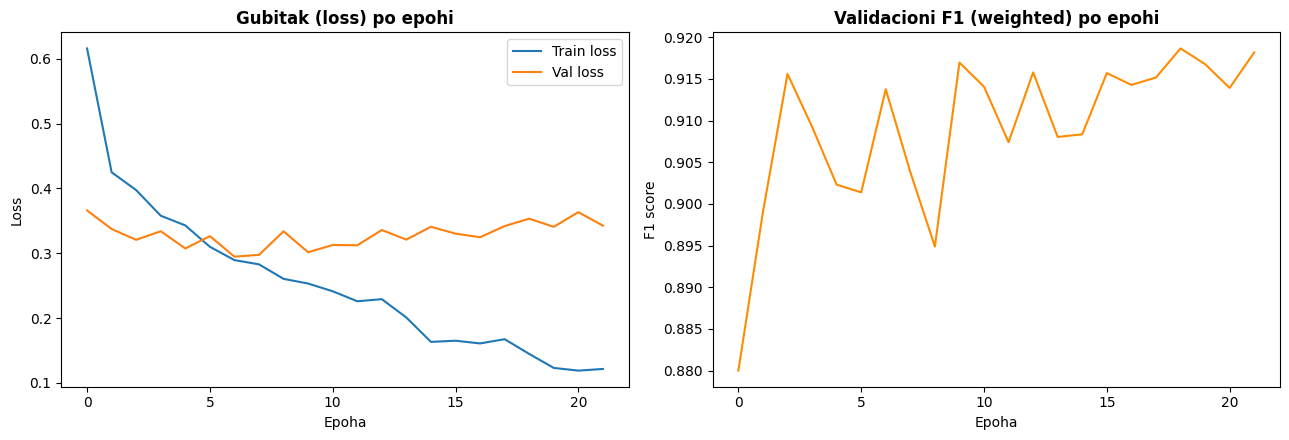

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history["train_loss"], label="Train loss")
axes[0].plot(history["val_loss"], label="Val loss")
axes[0].set_title("Gubitak (loss) po epohi", fontweight="bold")
axes[0].set_xlabel("Epoha")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["val_f1"], color="darkorange")
axes[1].set_title("Validacioni F1 (weighted) po epohi", fontweight="bold")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("F1 score")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_dl_sc_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

### Evaluacija na test skupu

In [31]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.numpy())
    return np.array(all_targets), np.array(all_preds)

y_train_true, y_train_pred = evaluate(model, DataLoader(train_dataset, batch_size=BATCH_SIZE))
y_test_true, y_test_pred = evaluate(model, test_loader)

train_acc = accuracy_score(y_train_true, y_train_pred)
train_f1 = f1_score(y_train_true, y_train_pred, average="weighted")
test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred, average="weighted")

print(f"Train Accuracy: {train_acc:.3f} | Train F1: {train_f1:.3f}")
print(f"Test Accuracy:  {test_acc:.3f} | Test F1:  {test_f1:.3f}")
print(f"Overfit Gap (F1): {train_f1 - test_f1:.3f}")
print()
print(classification_report(y_test_true, y_test_pred, target_names=le.classes_))

Train Accuracy: 0.977 | Train F1: 0.977
Test Accuracy:  0.896 | Test F1:  0.897
Overfit Gap (F1): 0.080

                      precision    recall  f1-score   support

           Hydrolase       0.93      0.90      0.92       441
            Receptor       0.92      0.91      0.91       276
  Structural protein       0.72      0.84      0.77       142
Transcription factor       0.97      0.94      0.95       269
   Transport protein       0.84      0.86      0.85       205

            accuracy                           0.90      1333
           macro avg       0.88      0.89      0.88      1333
        weighted avg       0.90      0.90      0.90      1333



### Matrica konfuzije

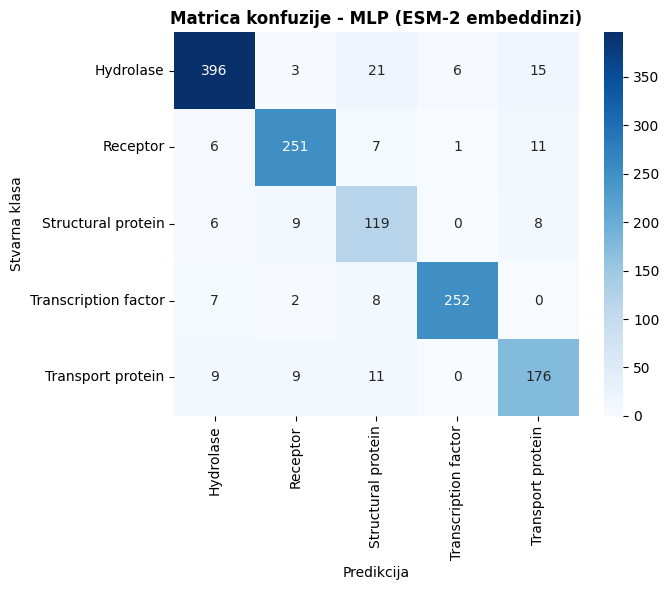

In [32]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title("Matrica konfuzije - MLP (ESM-2 embeddinzi)", fontweight="bold")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_dl_sc_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

### Čuvanje rezultata i modela

In [34]:
dl_results = {
    "Model": "MLP (PyTorch)",
    "Feature set": "ESM-2 embeddings",
    "Train Accuracy": train_acc,
    "Train F1 (weighted)": train_f1,
    "Test Accuracy": test_acc,
    "Test F1 (weighted)": test_f1,
    "Overfit Gap (F1)": train_f1 - test_f1,
    "Best epoch": len(history["train_loss"]) - PATIENCE,
    "Best val loss": best_val_loss,
}

# Cuvanje rezultata eksperimenta
dl_results_df = pd.DataFrame([dl_results])
dl_results_df.to_csv(os.path.join(RESULTS_DIR, "sc_dl_modeling_results.csv"), index=False)

# Cuvanje naucenih weights modela
torch.save(model.state_dict(), os.path.join(MODELS_DIR, "sc_dl_mlp_esm2.pt"))

# Cuvanje konfiguracije/arhitekture modela
with open(os.path.join(MODELS_DIR, "sc_dl_mlp_config.json"), "w") as f:
    json.dump({
        "input_dim": EMBEDDING_DIM,
        "num_classes": NUM_CLASSES,
        "hidden_dims": [256, 128],
        "dropout": 0.3,
    }, f, indent=2)

print("Rezultati i model sacuvani.")
dl_results_df

Rezultati i model sacuvani.


,Model,Feature set,Train Accuracy,Train F1 (weighted),Test Accuracy,Test F1 (weighted),Overfit Gap (F1),Best epoch,Best val loss
0,MLP (PyTorch),ESM-2 embeddings,0.977483,0.9775,0.895724,0.89728,0.080219,7,0.294712


### Poređenje sa klasičnim modelima 

In [35]:
classical_results = pd.read_csv(os.path.join(RESULTS_DIR, "sc_classical_modeling_results.csv"))
best_classical = classical_results.iloc[0]  # vec sortirano po Test F1 u notebooku 04

comparison_df = pd.DataFrame([
    {
        "Pristup": f"{best_classical['Model']} + {best_classical['Feature set']}",
        "Test Accuracy": best_classical["Test Accuracy"],
        "Test F1 (weighted)": best_classical["Test F1 (weighted)"],
    },
    {
        "Pristup": "MLP + ESM-2 embeddings",
        "Test Accuracy": test_acc,
        "Test F1 (weighted)": test_f1,
    },
])

print("Poredjenje najboljeg klasicnog modela i DL pristupa:\n")
print(comparison_df.to_string(index=False))

Poredjenje najboljeg klasicnog modela i DL pristupa:

               Pristup  Test Accuracy  Test F1 (weighted)
SVM + AAC-CV+TFIDF-SVD       0.818455            0.815547
MLP + ESM-2 embeddings       0.895724            0.897280


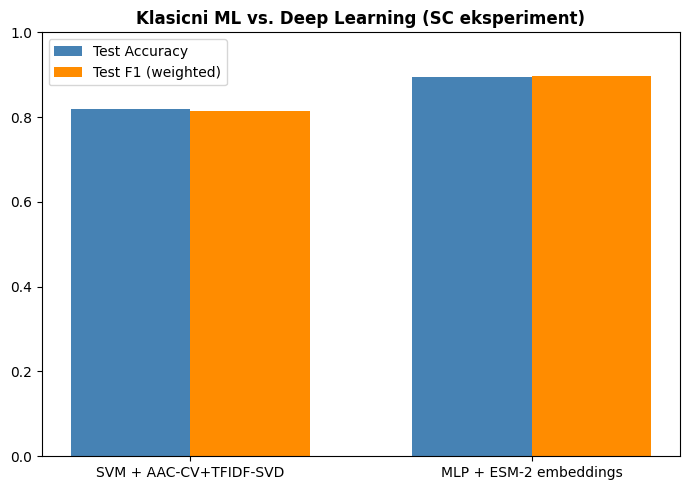

In [41]:
plt.figure(figsize=(7, 5))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df["Test Accuracy"], width, label="Test Accuracy", color="steelblue")
plt.bar(x + width/2, comparison_df["Test F1 (weighted)"], width, label="Test F1 (weighted)", color="darkorange")
plt.xticks(x, comparison_df["Pristup"])
plt.ylim(0, 1)
plt.title("Klasicni ML vs. Deep Learning (SC eksperiment)", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_dl_vs_classical_sc.png"), dpi=300, bbox_inches="tight")
plt.show()